# Tutorial 2: Contrastive Retrieval

This tutorial demonstrates contrastive learning approaches in NeuroVLM for:

1. **Brain-to-Text**: Labeling brain networks and activation maps
2. **Text-to-Brain**: Finding similar brain maps from text queries

We'll cover:
- Network labeling with canonical atlases
- ICA component labeling (HCP, UK Biobank)
- NeuroVault map labeling
- Text-to-brain retrieval across multiple datasets

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from neurovlm import NeuroVLM
from neurovlm.data import load_latent

# Initialize model
nvlm = NeuroVLM()

## 1. Brain-to-Text: Network Labeling

Given a brain network or activation map, we can retrieve the most semantically similar text from different datasets. This is useful for:
- Automatically labeling brain networks
- Understanding what cognitive processes are associated with activation patterns
- Validating network definitions against literature

***Note*** - The threshold serves as a relevance filter for Brain-to-text network labeling — terms appearing in the top-k results are not guaranteed to be meaningfully related to the neuroimaging data. A threshold of 0.4 is generally a reliable cutoff, as most brain-to-text scores above this value correspond to significant associations. While exceptions exist, this filter effectively removes spurious or unrelated terms.

### Load Network Atlases

We'll work with canonical brain networks from multiple atlases.

In [2]:
# Load pre-encoded network atlases
networks = load_latent("networks_neuro")

# Available atlases
print("Available atlases:")
for atlas_name in networks.keys():
    print(f"  {atlas_name}: {len(networks[atlas_name])} networks")

Available atlases:
  Du: 16 networks
  Glasser: 12 networks
  HCPICA: 20 networks
  Laird: 16 networks
  Shen: 8 networks
  Shirer: 13 networks
  UKBICA: 20 networks
  WashU: 30 networks
  Woodward: 12 networks
  YeoLab: 38 networks


### Example: Label the Auditory Network

In [3]:
# Use the auditory network from Du et al. atlas
auditory_network = networks["Du"]["AUD"]

# Find related text across all datasets
result = nvlm.brain(auditory_network).to_text()

# Show top 5 matches per dataset per dataset within threshold
top = result.top_k(5).query("cosine_similarity > 0.4")
top

,dataset,title,description,cosine_similarity
0,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245
3,cogatlas,acoustic phonetic processing,The cognitive ability to discriminate items on...,0.423635
4,cogatlas,auditory tone detection,Determining the presence of an auditory stimul...,0.417665
5,networks,Auditory,Auditory network (AUD; auditory cortex network...,0.470543
10,pubmed,The processing of temporal pitch and melody in...,An fMRI experiment was performed to identify t...,0.526884
11,pubmed,"Heschl's gyrus, posterior superior temporal gy...",A part of the auditory system automatically de...,0.504547
12,pubmed,Hierarchical processing of sound location and ...,Horizontal sound localization relies on the ex...,0.499913
13,pubmed,Brain bases for auditory stimulus-driven figur...,"Auditory figure-ground segregation, listeners'...",0.490401


### Query Specific Datasets

You can also search specific datasets like Cognitive Atlas concepts, tasks, or disorders.

In [4]:
# Find related cognitive concepts
result = nvlm.brain(auditory_network).to_text()
concepts = result.top_k(5, dataset="cogatlas")
print("\nTop Cognitive Atlas Concepts:")
concepts


Top Cognitive Atlas Concepts:


,dataset,title,description,cosine_similarity
0,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245
3,cogatlas,acoustic phonetic processing,The cognitive ability to discriminate items on...,0.423635
4,cogatlas,auditory tone detection,Determining the presence of an auditory stimul...,0.417665


In [5]:
# Find related scientific papers
papers = result.top_k(5, dataset="pubmed")
print("\nTop Related Papers:")
papers


Top Related Papers:


,dataset,title,description,cosine_similarity
0,pubmed,The processing of temporal pitch and melody in...,An fMRI experiment was performed to identify t...,0.526884
1,pubmed,"Heschl's gyrus, posterior superior temporal gy...",A part of the auditory system automatically de...,0.504547
2,pubmed,Hierarchical processing of sound location and ...,Horizontal sound localization relies on the ex...,0.499913
3,pubmed,Brain bases for auditory stimulus-driven figur...,"Auditory figure-ground segregation, listeners'...",0.490401
4,pubmed,Dichotic pitch activates pitch processing cent...,Although several neuroimaging studies have rep...,0.485120


In [6]:
# Find related Wikipedia entries
wiki = result.top_k(5, dataset="wiki")
print("\nTop NeuroWiki Entries:")
wiki


Top NeuroWiki Entries:


,dataset,title,description,cosine_similarity
0,wiki,Temporal masking,Temporal masking or non-simultaneous masking o...,0.489581
1,wiki,Melodic expectation,"In music cognition and musical analysis, the s...",0.454363
2,wiki,Search by sound,Search by sound is the retrieval of informatio...,0.452222
3,wiki,Beat (acoustics),"In acoustics, a beat is an interference patter...",0.447247
4,wiki,Harmonic series (music),The harmonic series (also overtone series) is ...,0.446160


### Example: Label the Default Mode Network

In [7]:
# Default mode network from Yeo et al. atlas
dmn = networks["YeoLab"]["DefaultA"]

result = nvlm.brain(dmn).to_text()

# top 5 matches per dataset within threshold
top = result.top_k(5).query("cosine_similarity > 0.4")
top

,dataset,title,description,cosine_similarity
5,networks,Default Mode,Default mode network (DMN; default network; de...,0.467490
10,pubmed,The Self-Concept Is Represented in the Medial ...,"Knowledge about one's personality, the self-co...",0.504036
11,pubmed,Resting state fMRI in Alzheimer's disease: bey...,Using resting state (RS) functional magnetic r...,0.481533
12,pubmed,Reduced functional coupling in the default-mod...,Activity within the default-mode network (DMN)...,0.479043
13,pubmed,Regional amyloid burden and intrinsic connecti...,Although previous studies demonstrated decreas...,0.473489
14,pubmed,Associations and dissociations between default...,Neuroimaging has revealed consistent activatio...,0.472962
15,wiki,Default mode network,"In neuroscience, the default mode network (DMN...",0.469827
16,wiki,TheBrain,"TheBrain, formerly branded PersonalBrain, is a...",0.422660
17,wiki,Oxygen,Oxygen is a chemical element; it has symbol O ...,0.410480
18,wiki,2C-O,"2C-O, also known as 2,4,5-trimethoxyphenethyla...",0.408183


### Example: Label a Motor Network

In [8]:
# Somatomotor network
motor = networks["YeoLab"]["SomMotA"]

result = nvlm.brain(motor).to_text()
top = result.top_k(5).query("cosine_similarity > 0.4")
top

,dataset,title,description,cosine_similarity
0,cogatlas,motor control,The function of supervising motor activities.,0.471245
5,networks,Motor,Motor network (motor/sensorimotor network; SMN...,0.503942
10,pubmed,The hand motor hotspot for seed-based function...,In the seed-based method for studying function...,0.522147
11,pubmed,Convergence of human brain mapping tools: neur...,Functional magnetic resonance imaging (fMRI) a...,0.499828
12,pubmed,The role of the contralesional motor cortex fo...,Stroke may trigger a number of cellular and mo...,0.496707
13,pubmed,High-sensitivity TMS/fMRI of the Human Motor C...,To validate a novel setup for concurrent TMS/f...,0.496136
14,pubmed,Re-thinking the role of motor cortex: context-...,The standard account of motor control consider...,0.489319
15,wiki,Nonprimary motor cortex,Nonprimary motor cortex is a functionally defi...,0.482699
16,wiki,Motor evoked potentials,Motor evoked potentials (MEP) are recorded fro...,0.465895
17,wiki,Motor unit recruitment,Motor unit recruitment is the activation of ad...,0.462458


## 2. ICA Component Labeling

Independent Component Analysis (ICA) is commonly used to identify brain networks from resting-state fMRI data (e.g., HCP, UK Biobank). NeuroVLM can automatically label these components.

In [9]:
# Example: Label ICA components from the HCP ICA atlas
ica_component = networks["HCPICA"]["ICA10"]

result = nvlm.brain(ica_component).to_text()
top = result.top_k(3)
print("ICA Component 10 is most similar to:")
top

ICA Component 10 is most similar to:


,dataset,title,description,cosine_similarity
0,cogatlas,spatial attention,The allocation or prioritization of mental res...,0.272954
1,cogatlas,body representation,A mental representation of one&#39;s own body.,0.270264
2,cogatlas,action,The bringing about of an alteration by force o...,0.258443
3,networks,Attention,Dorsal attention network [SEP] Primary regions...,0.288401
4,networks,Motor,Motor network (motor/sensorimotor network; SMN...,0.272677
5,networks,Visual,Visual network (VIS; occipital visual network)...,0.177256
6,pubmed,The organization of the posterior parietal cor...,The present fMRI study examined whether upper-...,0.490899
7,pubmed,Imagined tool-use in near and far space modula...,Active tool-use can result in the incorporatio...,0.483578
8,pubmed,The representation of tool use in humans and m...,Though other species of primates also use tool...,0.482804
9,wiki,Rubber hand illusion,The rubber hand illusion was originally report...,0.387989


## 3. NeuroVault Map Labeling

For arbitrary brain activation maps (e.g., from your own study or NeuroVault), you can:
1. Load the NIfTI image
2. Query it against text datasets

In [10]:
# Example with visual network
visual_network = networks["YeoLab"]["VisualA"]

result = nvlm.brain(visual_network).to_text()
top = result.top_k(5)
print("Visual Network Labels:")
top

Visual Network Labels:


,dataset,title,description,cosine_similarity
0,cogatlas,object perception,The process of transforming basic visual senso...,0.452152
1,cogatlas,animacy perception,The ability to appropriately perceive that ano...,0.447128
2,cogatlas,visual search,Orienting for targets in an array or a natural...,0.432990
3,cogatlas,figure ground segregation,Discriminating objects from their surroundings...,0.413456
4,cogatlas,feature detection,A process of recognizing specific aspects of a...,0.403889
5,networks,Visual,Visual network (VIS; occipital visual network)...,0.470024
6,networks,Attention,Dorsal attention network [SEP] Primary regions...,0.139859
7,networks,Motor,Motor network (motor/sensorimotor network; SMN...,-0.094210
8,networks,Auditory,Auditory network (AUD; auditory cortex network...,-0.110284
9,networks,Default Mode,Default mode network (DMN; default network; de...,-0.113557


## 4. Text-to-Brain: Finding Similar Brain Maps

Given a text query, retrieve the most similar brain activation patterns from datasets.

Note - The brain-to-text filtering threshold of 0.4 does not apply to text-brain

### Example: Find brain maps for "emotion processing"

In [11]:
# Search across all brain datasets
result = nvlm.text("emotion processing").to_brain(head="infonce")

# Get top 5 matches
top = result.top_k(5)
top.table = top.table.sort_values('cosine_similarity', ascending=False).reset_index(drop=True)
top

There are adapters available but none are activated for the forward pass.


,dataset,dataset_index,title,description,cosine_similarity
0,pubmed,10250,Acute pharmacologically induced shifts in sero...,Pharmacological manipulation of serotonin avai...,0.440253
1,pubmed,10299,Passive and motivated perception of emotional ...,Emotionally expressive faces are processed by ...,0.438481
2,pubmed,10410,Interaction of catechol O-methyltransferase an...,Imaging genetic studies showed exaggerated blo...,0.437990
3,pubmed,597,Effects of attention and emotion on repetition...,We examined whether behavioral and neural effe...,0.411406
4,pubmed,5477,Psychopathy and functional magnetic resonance ...,Comorbidity between schizophrenia and psychopa...,0.408612
5,neurovault,682,Synchrony between sensory and cognitive networ...,Individuals with autistic spectrum disorders e...,0.350966
6,neurovault,369,Affective brain patterns as multivariate neura...,This study tested whether brain activity patte...,0.346154
7,neurovault,368,Affective brain patterns as multivariate neura...,This study tested whether brain activity patte...,0.346154
8,neurovault,1484,Early childhood stress is associated with blun...,Early life stress increases risk for later psy...,0.314913
9,neurovault,661,Synchrony between sensory and cognitive networ...,Individuals with autistic spectrum disorders e...,0.308400


### Example: Search specific brain datasets

In [12]:
# Search only in canonical networks
result = nvlm.text("attention").to_brain(head="infonce", dataset="networks")
top = result.top_k(3)
print("Top attention-related networks:")
top

Top attention-related networks:


,dataset,dataset_index,title,description,cosine_similarity
0,networks,31,HCPICA,ICA4,0.347036
1,networks,70,Shen,visual association,0.325007
2,networks,75,Shirer,HighVisual,0.322428


In [13]:
# Search only in PubMed activation maps
result = nvlm.text("working memory").to_brain(head="infonce", dataset="pubmed")
top = result.top_k(3)
print("Top working memory studies:")
top

Top working memory studies:


,dataset,dataset_index,title,description,cosine_similarity
0,pubmed,1581,Control networks and hemispheric asymmetries i...,Neuropsychological research has consistently d...,0.405711
1,pubmed,6428,Salience maps in parietal cortex: imaging and ...,Models of spatial attention are often based on...,0.405312
2,pubmed,22999,Effects of in-Scanner Bilateral Frontal tDCS o...,Working memory is an executive memory process ...,0.399832


### Example: Multi-dataset retrieval

In [14]:
# Search across multiple datasets
result = nvlm.text("language comprehension").to_brain(
    head="infonce",
    dataset=["networks", "neurovault"]
)
top = result.top_k(5)
top.table = top.table.sort_values('cosine_similarity', ascending=False).reset_index(drop=True)
top

,dataset,dataset_index,title,description,cosine_similarity
0,neurovault,2,Reliable individual-level neural markers of hi...,The majority of functional neuroimaging invest...,0.468160
1,neurovault,1601,Knowing what you need to know in advance: The ...,"Semantic retrieval is flexible, allowing us to...",0.433621
2,neurovault,543,Functional Connectivity in the Social Brain ac...,Previous research has characterized a collecti...,0.404827
3,neurovault,2591,Oxytocin Enhances an Amygdala Circuit Associat...,Negative symptoms are core contributors to voc...,0.400779
4,neurovault,2490,Evolution of reading and face circuits during ...,Although words and faces activate neighboring ...,0.398940
5,networks,63,Laird,DivergentCog6,0.393426
6,networks,21,Glasser,Language,0.340999
7,networks,44,HCPICA,ICA18,0.338026
8,networks,123,WashU,VentAttn,0.334167
9,networks,150,YeoLab,Language,0.315106


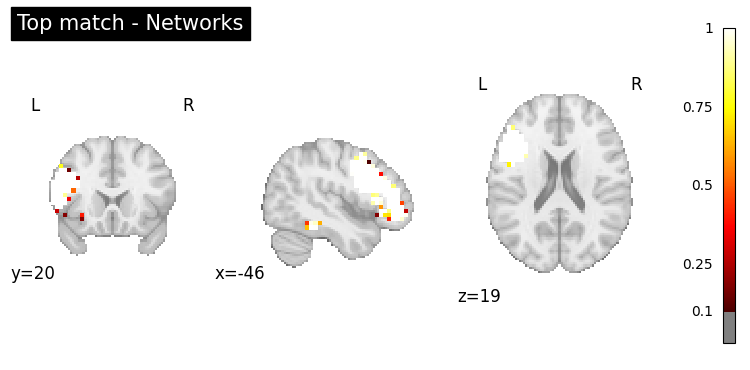

In [15]:
# Plot top matches from different datasets
top.plot_row(0, threshold=0.1, title="Top match - Networks");

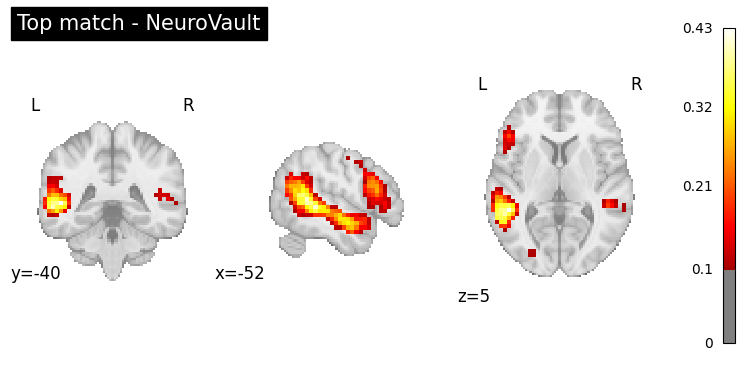

In [16]:
top.plot_row(5, threshold=0.1, title="Top match - NeuroVault");

## 5. Comparing Multiple Queries

You can run multiple queries at once and compare results.

In [17]:
# Multiple text queries
queries = [
    "visual perception",
    "motor control",
    "executive function"
]

result = nvlm.text(["vision", "default mode network"]).to_brain(head="mse")
result.to_nifti() # returns list of nib.Nifti1Image

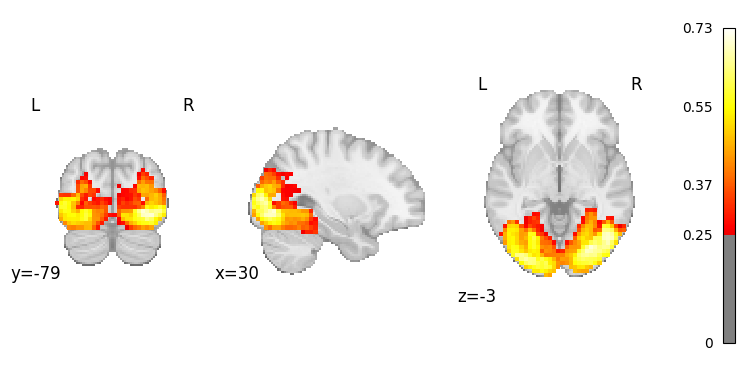

In [18]:
result.plot(0, threshold=0.25); # plot image for vision

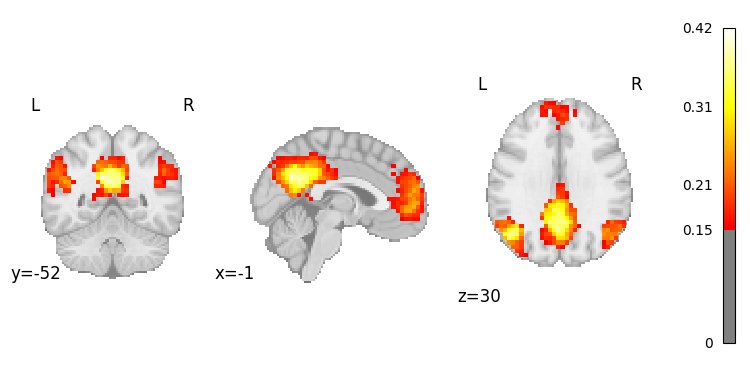

In [19]:
result.plot(1, threshold=0.15); # plot image for DMN

## 6. Batch Network Labeling

Label multiple networks at once for systematic comparison.

In [20]:
# Select multiple networks to label
import torch

network_names = ["VIS-P", "AUD", "SMOT-A", "DN-A", "LANG"]
network_latents = [networks["Du"][name] for name in network_names]

# Stack into batch
batch = torch.stack(network_latents)

# Label all at once
result = nvlm.brain(batch).to_text()

# Show top concept for each network
results = []
for i, name in enumerate(network_names):
    print(f"\n=== {name} ===")
    top = result.top_k(3, query_index=i, dataset="cogatlas")
    results.append(top)


=== VIS-P ===

=== AUD ===

=== SMOT-A ===

=== DN-A ===

=== LANG ===


In [21]:
results[0] # top concepts for "VIS-P"

,query_index,dataset,title,description,cosine_similarity
0,0,cogatlas,visual memory,A part of memory preserving some characteristi...,0.258297
1,0,cogatlas,perception,The conscious experience or mental registratio...,0.254730
2,0,cogatlas,object perception,The process of transforming basic visual senso...,0.251840


In [22]:
results[1] # top concepts for "AUD"

,query_index,dataset,title,description,cosine_similarity
0,1,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,1,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245


In [23]:
results[2] # top concepts for SMOT-A network

,query_index,dataset,title,description,cosine_similarity
0,2,cogatlas,motor control,The function of supervising motor activities.,0.438986
1,2,cogatlas,interoceptive representation,A representation of the internal state of the ...,0.358093
2,2,cogatlas,kinesthesia,A sense mediated by receptors located in muscl...,0.316170


## 7. Summary

In this tutorial, you learned:

1. **Brain-to-Text** retrieval:
   - Network labeling using canonical atlases
   - ICA component labeling
   - Querying specific datasets (PubMed, Cognitive Atlas, NeuroWiki)
   
2. **Text-to-Brain** retrieval:
   - Finding similar brain maps from text queries
   - Searching specific datasets (networks, neurovault, pubmed)
   - Multi-dataset retrieval
   
3. **Advanced usage**:
   - Batch processing multiple queries
   - Systematic network labeling

**Next**: In Tutorial 3, you'll learn how to generate brain activation maps from text using the generative approach.